In [ ]:
import os
import shutil

# Function to analyze the dataset and check for missing folders or issues
def analyze_and_clean_dataset(dataset_dir):
    """
    Analyze the dataset for missing folders and drop them if necessary.

    Args:
    - dataset_dir (str): Path to the root directory of the dataset.

    Returns:
    - summary (dict): Dictionary containing dataset analysis summary.
    """
    summary = {
        "total_classes": 0,
        "total_images": 0,
        "missing_folders": [],
        "processed_folders": [],
        "dropped_folders": []
    }

    # Iterate over each class folder
    for class_name in os.listdir(dataset_dir):
        class_path = os.path.join(dataset_dir, class_name)
        if os.path.isdir(class_path):
            summary["total_classes"] += 1

            # Check if the folder contains at least one image
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

            if image_files:
                summary["total_images"] += len(image_files)
                summary["processed_folders"].append(class_name)
            else:
                # Mark folder as missing if no images are found
                summary["missing_folders"].append(class_name)
                shutil.rmtree(class_path)  # Optionally delete the folder
                summary["dropped_folders"].append(class_name)

    return summary

# Specify the dataset directory (LAMPHQ dataset path)
dataset_dir = "LAMPHQ"  # Replace with your actual dataset path

# Run the analysis and cleanup
dataset_summary = analyze_and_clean_dataset(dataset_dir)

# Print the summary
print("Dataset Analysis Summary:")
print(f"Total Classes: {dataset_summary['total_classes']}")
print(f"Total Images: {dataset_summary['total_images']}")
print(f"Missing Folders (No Images): {len(dataset_summary['missing_folders'])}")
print(f"Processed Folders: {len(dataset_summary['processed_folders'])}")
print(f"Dropped Folders: {len(dataset_summary['dropped_folders'])}")

if dataset_summary['dropped_folders']:
    print("\nDropped Folders:")
    for folder in dataset_summary['dropped_folders']:
        print(f"- {folder}")
else:
    print("\nNo folders were dropped.")


Dataset Analysis Summary:
Total Classes: 573
Total Images: 56788
Missing Folders (No Images): 0
Processed Folders: 573
Dropped Folders: 0

No folders were dropped.


In [ ]:
import os
from PIL import Image, ImageEnhance, ImageOps
from torchvision import transforms

# Function to apply histogram equalization, split into 3 channels, and save images
def preprocess_and_save_images(input_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    transform_resized = transforms.Resize((224, 224))

    for root, _, files in os.walk(input_dir):
        for file in files:
            if file.endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                file_path = os.path.join(root, file)
                image = Image.open(file_path).convert("L")  # Convert to grayscale

                # Step 1: Apply Histogram Equalization
                equalized_image = ImageOps.equalize(image)

                # Step 2: Apply contrast adjustments to create 3 channels
                enhancer = ImageEnhance.Contrast(equalized_image)
                low_contrast = enhancer.enhance(0.5)
                mid_contrast = equalized_image  # Equalized image as mid contrast
                high_contrast = enhancer.enhance(1.5)

                # Step 3: Merge the 3 contrast-adjusted images as RGB channels
                combined_image = Image.merge("RGB", (low_contrast, mid_contrast, high_contrast))
                combined_image = transform_resized(combined_image)

                # Step 4: Save the combined image to the output directory with the same folder structure
                rel_path = os.path.relpath(file_path, input_dir)
                save_path = os.path.join(output_dir, rel_path)
                os.makedirs(os.path.dirname(save_path), exist_ok=True)
                combined_image.save(save_path)

# Define input and output directories
input_dir = 'LAMPHQ'  # Change this to your actual dataset path
output_dir = 'processed_dataset_HE_LAMPHQ'

# Run the function
preprocess_and_save_images(input_dir, output_dir)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import os

# Assumption: The preprocessed dataset already has three contrast-adjusted channels and is stored as 3-channel images.

data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),  # Mirror augmentation
    transforms.RandomRotation(15),  # Orientation augmentation
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Adjust lighting variability
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Use single-channel values if grayscale
])


# Load the preprocessed 3-channel contrast dataset
data_dir = 'processed_dataset_HE_LAMPHQ'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split dataset into training, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders with a modest batch size
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader, 'test': test_loader}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}

# Get class names and count
class_names = full_dataset.classes
num_classes = len(class_names)
print("Number of classes:", num_classes)





Number of classes: 573


In [ ]:
# Model modification with Dropout
class SimpleResNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, num_classes)
        )
    def forward(self, x):
        return self.backbone(x)

# Initialize model, optimizer, and criterion
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleResNet(num_classes=num_classes).to(device)
# Optimizer with weight decay
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
# Scheduler for learning rate adjustment
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:

# Training function with early stopping
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5):
    best_acc = 0.0
    epochs_no_improve = 0
    best_model_wts = model.state_dict()

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)
        scheduler.step()

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                    # Calculate accuracy
                    _, preds = torch.max(outputs, 1)
                    running_corrects += torch.sum(preds == labels)
                running_loss += loss.item() * inputs.size(0)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Early stopping check for validation accuracy
            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = model.state_dict()
                    epochs_no_improve = 0  # Reset counter if accuracy improves
                    torch.save(model.state_dict(), 'simple_resnet_best_LAMPHQ.pth')  # Save the best model
                    print("Model improved and saved.")
                else:
                    epochs_no_improve += 1  # Increment counter if no improvement

                if epochs_no_improve >= patience:
                    print("Early stopping triggered.")
                    model.load_state_dict(best_model_wts)
                    return model  # Return the best model early

    # Load the best model weights before returning
    model.load_state_dict(best_model_wts)
    return model

# Train the model with early stopping
model = train_model(model, dataloaders, criterion, optimizer, num_epochs=25, patience=5)


Epoch 1/25
----------


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:216: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


train Loss: 5.0551 Acc: 0.0761
val Loss: 2.8701 Acc: 0.3206
Model improved and saved.
Epoch 2/25
----------
train Loss: 2.2686 Acc: 0.4479
val Loss: 1.1135 Acc: 0.7161
Model improved and saved.
Epoch 3/25
----------
train Loss: 1.0148 Acc: 0.7539
val Loss: 0.4121 Acc: 0.8962
Model improved and saved.
Epoch 4/25
----------
train Loss: 0.5228 Acc: 0.8787
val Loss: 0.2019 Acc: 0.9533
Model improved and saved.
Epoch 5/25
----------
train Loss: 0.3032 Acc: 0.9341
val Loss: 0.1138 Acc: 0.9721
Model improved and saved.
Epoch 6/25
----------
train Loss: 0.1970 Acc: 0.9603
val Loss: 0.0817 Acc: 0.9803
Model improved and saved.
Epoch 7/25
----------
train Loss: 0.1059 Acc: 0.9829
val Loss: 0.0399 Acc: 0.9920
Model improved and saved.
Epoch 8/25
----------
train Loss: 0.0829 Acc: 0.9887
val Loss: 0.0352 Acc: 0.9933
Model improved and saved.
Epoch 9/25
----------
train Loss: 0.0723 Acc: 0.9905
val Loss: 0.0320 Acc: 0.9937
Model improved and saved.
Epoch 10/25
----------
train Loss: 0.0675 Acc: 0.9

In [ ]:
# Testing function
def test_model(model, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%')

# Test the model
test_model(model, test_loader, criterion)

Test Loss: 0.0302, Test Accuracy: 99.40%


C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_25712\2950159095.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("simple_resnet_best_LAM

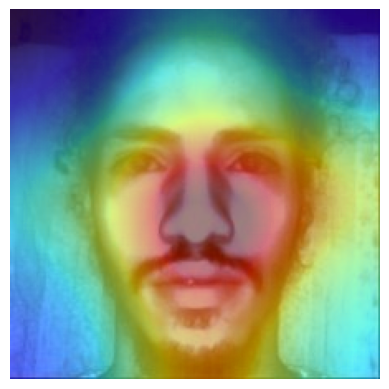

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# Grad-CAM Class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None

        # Register hooks to capture gradients and features
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass for the predicted class
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]

        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Preprocess a single image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Match training image size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Match training normalization
    ])
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel image
    input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return input_tensor, image

# Overlay Grad-CAM heatmap on the original image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.axis('off')
    plt.show()

# Load the trained model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleResNet(num_classes=573).to(device)  # Replace 720 with the number of classes in your dataset
model.load_state_dict(torch.load("simple_resnet_best_LAMPHQ.pth", map_location=device))
model.eval()

# Instantiate Grad-CAM
target_layer = model.backbone.layer4[-1]  # Last layer of ResNet backbone
grad_cam = GradCAM(model, target_layer)

# Generate Grad-CAM heatmap for a single image
image_path = "processed_dataset_HE_LAMPHQ\\FP0001\\NIR_FP0001_1_DOWN_a.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)


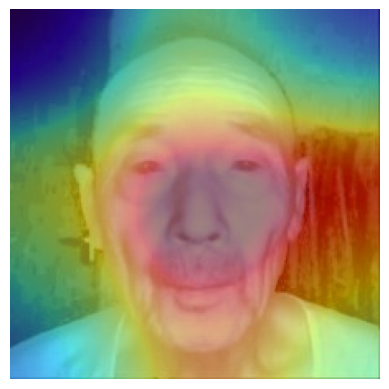

In [ ]:

# Generate Grad-CAM heatmap for a single image
image_path = "processed_dataset_HE_LAMPHQ\\P0022\\NIR_P0022_2_DOWN_a.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

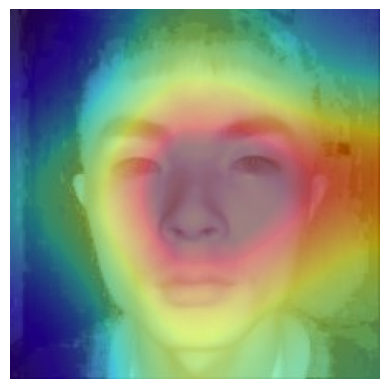

In [ ]:
# Generate Grad-CAM heatmap for a single image
image_path = "processed_dataset_HE_LAMPHQ\\P0587\\NIR_P0587_1_RIGHT_e.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)

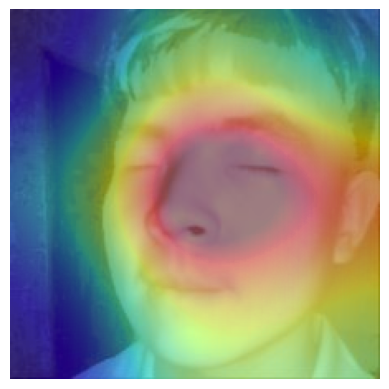

In [ ]:

# Generate Grad-CAM heatmap for a single image
image_path = "processed_dataset_HE_LAMPHQ\\P0530\\NIR_P0530_1_RIGHT_d.jpg"  # Replace with the path to your test image
input_tensor, original_image = preprocess_image(image_path)
heatmap = grad_cam(input_tensor)
overlay_heatmap(original_image, heatmap)